# 03 · Building and Training the Model

**IUM teaching series, Notebook 3/4** · Wang & Zhao, *Additive Manufacturing*
(2026) 105300.

We now have features. This notebook turns them into a working soft sensor:

1. assemble the **344-dimensional** sample representation;
2. choose how to split the data for training and testing — and see why that
   choice decides whether the reported numbers mean anything;
3. build and train the **three-branch attention-fusion network**.


## Machine-learning vocabulary used in this notebook

| term | what it means here |
|---|---|
| **sample** | one printed cylinder. We have exactly **50** of them — a small dataset, which is why every methodological detail matters. |
| **feature / representation** | the numbers describing one sample. Ours is 344-dimensional: 330 layer-wise values + 12 part-scale statistics + 2 printing conditions. |
| **label / target** | the ground truth we want to predict: thickness (Keyence profilometer, mm), storage modulus (rheometer, Pa), degree of conversion (Raman, 0–1). |
| **cross-validation (CV), fold** | to estimate performance honestly you split the data, train on one part and test on the other, and repeat. Each repetition is a *fold*. |
| **data leakage** | when information about the test samples reaches the model during training. The reported score then measures memorisation, not generalisation. This notebook shows a real example. |
| **LOIO** | *Leave-One-Intensity-Out*: each fold holds out **all** samples printed at one exposure intensity, so the model must predict a light dose it has never seen. |
| **StandardScaler** | rescales each column to zero mean / unit variance. Critically, it must be **fitted on the training fold only** — fitting it on all data is itself a form of leakage. |
| **epoch** | one pass of the training algorithm over the whole training set. |
| **R²** | fraction of the label's variance the model explains: 1.0 is perfect, 0 is no better than predicting the mean, and negative values are worse than that. |


### Before we run anything: the setup cell

**Input** — nothing from your side. On Google Colab this cell downloads the
course repository (`github.com/wangyiquan1010-coder/IUM_teaching_colab`), which
ships *all* the data used in this series; running locally, it just finds the
repository folder you already have.

**What this cell does** — clones the repo if needed, moves the working
directory to the repository root (so that every later path like
`data/feature11.csv` resolves), and imports the four things we use everywhere:
`numpy` (signal math), `pandas` (tables), `matplotlib` (plots) and
`ium_utils` — **our own teaching library**, a clean, read-only refactor of the
paper's code that lives in `src/ium_utils.py`. Feel free to open that file at
any point: every function used in the notebooks is defined there, with comments.

**Output** — the imported modules plus a confirmation line printing the
repository root. Nothing is computed yet.


In [1]:
# --- Setup (works both locally and on Google Colab) ---------------------------
# On Colab the notebook starts in an empty machine, so we first download
# ("clone") the whole course repository, which contains the data, the helper
# library and the figures. Locally the files are already next to the notebook,
# so the clone is skipped.
import os, sys

if "google.colab" in sys.modules and not os.path.exists("src"):
    !git clone -q https://github.com/wangyiquan1010-coder/IUM_teaching_colab.git
    %cd IUM_teaching_colab

# Walk up the folder tree until we find the repository root (the folder that
# contains src/). This makes every later path such as "data/feature11.csv"
# work no matter where the notebook was launched from.
_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, "src")):
    _parent = os.path.dirname(_here)
    if _parent == _here:
        raise FileNotFoundError("repo root with src/ not found")
    _here = _parent
os.chdir(_here)
sys.path.insert(0, "src")            # so that "import ium_utils" works

import numpy as np                   # arrays / signal math
import pandas as pd                  # tables (features, labels, results)
import matplotlib.pyplot as plt      # static plots
from matplotlib import rc
rc("animation", html="jshtml")       # render animations as interactive players
import ium_utils as iu               # OUR course library (see src/ium_utils.py)
print("setup ok — repo root:", _here)


setup ok — repo root: C:\Users\wangy\Desktop\IUM_teaching_colab


## 1. Assemble the dataset

Each printed sample becomes: 330 layer-wise entries (11 features × 30 layer
slots, zero-padded) + 12 part-scale statistics + 2 printing conditions,
with three labels (thickness, modulus, DoC) from Keyence / rheometer / Raman.

---

**Input** — two CSV files that together *are* the paper's dataset:

- `data/feature11.csv` — the feature table produced by the paper's extraction
  pipeline from all 50 prints (the same file we sanity-checked against our own
  recomputation in Notebook 2);
- `data/condition_labels.csv` — the measured ground truth for the same 50
  prints, in the same row order: `thickness` (mm, Keyence laser profilometer),
  `modulus` (Pa, rheometer) and `DoC` (dimensionless 0–1, Raman spectroscopy).

**What this cell does** — loads both tables, asserts that their rows really do
line up (the `assert` is a cheap guard against the single most common and most
embarrassing data bug: silently mismatched features and labels), and merges the
three label columns into one wide table called `full`.

**Output** — `full`: 50 rows × (330 layer-wise features + `layer` + `intensity`
+ 3 labels). Every remaining cell in this notebook reads from it.


In [2]:
# Features (from raw ultrasound) and labels (from destructive/offline metrology)
# live in two files with matching row order — one row per printed sample.
feats = iu.load_features("data/feature11.csv")
labels = iu.load_labels("data/condition_labels.csv")

# Guard against the classic silent bug: features and labels out of order.
assert (feats.layer.values == labels.layer.values).all()

full = feats.copy()
for c in iu.LABEL_COLS:                 # thickness, modulus, DoC
    full[c] = labels[c]

print(f"{len(full)} samples;  layer counts {sorted(full.layer.unique())};  "
      f"intensities {sorted(full.intensity.unique())} (% of max power)")
full[["layer", "intensity"] + iu.LABEL_COLS].head()


50 samples;  layer counts [np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30)];  intensities [np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100)] (% of max power)


,layer,intensity,thickness,modulus,DoC
0,10,10,1.227,982.16,0.702387
1,10,20,1.273,2029.10,0.719417
2,10,30,1.365,6675.70,0.711217
3,10,40,1.439,2478.80,0.725419
4,10,50,1.412,14277.00,0.738471


## 2. How we split the data — and why it decides everything

Before training anything, we have to choose which samples the model is tested
on. The obvious choice is a random split: shuffle the 50 prints, train on 40,
test on 10. For this dataset that choice is wrong, and badly so.

The reason is the design of the experiment. Each exposure intensity was printed
five times, at five different layer counts. So if a randomly held-out print was
made at 70% lamp power, four other prints at exactly 70% are still in the
training set. The model does not have to understand the ultrasound at all: it
can look up `intensity = 70`, recall what those neighbours looked like, and
interpolate. The score that comes out measures memorisation of the recipe, not
sensing.

What a deployed sensor actually faces is a print whose settings it has never
seen. So we hold out **one whole intensity at a time**: all five prints made at
that lamp power go into the test set together, and the model must extrapolate
to it. Ten intensities, ten folds — **Leave-One-Intensity-Out (LOIO)**. Let's
measure how much the choice is worth, using a fast Random Forest so the
comparison is about the protocol and not the model.

---

**Input** — the full 344-dimensional representation built from `full`: the 330
layer-wise features, the 2 process columns (`layer`, `intensity`) and the 12
part-scale statistics computed by `iu.part_scale_stats()` (mean, max, std,
slope, early-vs-late difference and final value of the ToF and amplitude
sequences, using only each print's *real* layers, not the zero padding).

**What this cell does** — trains the *same* Random Forest under two evaluation
protocols and nothing else changes: (a) random 5-fold, which scatters the 50
samples arbitrarily, and (b) Leave-One-Intensity-Out, where `groups=intensity`
forces every fold to hold out all five prints made at one light dose. A Random
Forest is used here instead of the neural network purely because it trains in
seconds, so the comparison is about the *protocol*, not the model.

**Output** — the bar chart and the `comp` table of R² per target under both
protocols. The distance between the two bars is the leakage.


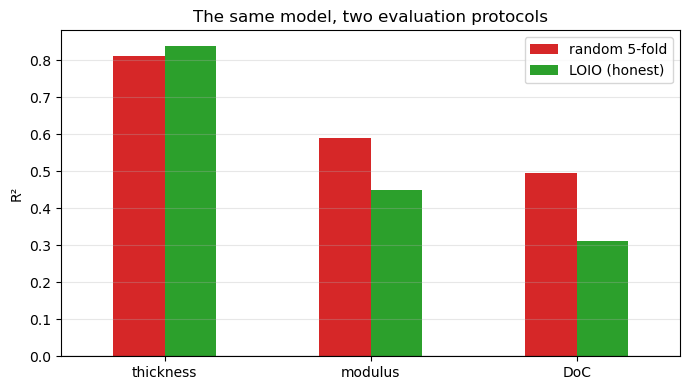

,random 5-fold,LOIO (honest)
thickness,0.811,0.839
modulus,0.591,0.449
DoC,0.496,0.311


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, LeaveOneGroupOut
from sklearn.metrics import r2_score

# Build the sample representation: 330 layer-wise + 2 process + 12 part-scale.
seq_cols = iu.seq_columns(full)                   # the 330 Layer_{i}_{feature} columns
X = full[seq_cols + ["layer", "intensity"]].values
X_stats = iu.part_scale_stats(full).values        # 12 global descriptors
X_all = np.hstack([X, X_stats])
Y = full[iu.LABEL_COLS].values                    # 50 × 3 labels

def cv_r2(splitter, groups=None):
    """Run any CV splitter and return out-of-fold R² for the three targets.

    Every sample is predicted exactly once, by a model that did not see it
    during training — that is what makes the score 'out-of-fold'.
    """
    preds = np.zeros_like(Y)
    for tr_idx, te_idx in splitter.split(X_all, Y, groups):
        rf = RandomForestRegressor(300, random_state=0, n_jobs=-1)
        rf.fit(X_all[tr_idx], Y[tr_idx])
        preds[te_idx] = rf.predict(X_all[te_idx])
    return [r2_score(Y[:, i], preds[:, i]) for i in range(3)]

# (a) Optimistic: random folds — a held-out print's own intensity is still in training.
r2_random = cv_r2(KFold(5, shuffle=True, random_state=0))
# (b) Honest: whole intensity groups held out — the model must extrapolate.
r2_loio = cv_r2(LeaveOneGroupOut(), groups=full.intensity.values)

comp = pd.DataFrame({"random 5-fold": r2_random, "LOIO (honest)": r2_loio},
                    index=iu.LABEL_COLS).round(3)
ax = comp.plot.bar(figsize=(7, 4), rot=0, color=["tab:red", "tab:green"])
ax.set_ylabel("R²"); ax.set_title("The same model, two evaluation protocols")
ax.axhline(0, color="k", lw=0.8); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()
comp


**The gap you just plotted is the leakage.** Random K-fold flatters every
metric because the test intensity was always seen in training. LOIO forces
*extrapolation to unseen process settings* — which is exactly the deployment
scenario for a real sensor.

> Three leak-free rules used from here on (and in the paper): ① the test
> intensity is absent from training; ② every scaler is fitted on the training
> partition only; ③ any augmentation would be applied to training folds only.

## 3. The model — three-branch attention fusion

<img src="https://raw.githubusercontent.com/wangyiquan1010-coder/IUM_teaching_colab/main/figs/model_architecture.png"
     alt="model architecture" style="max-width:100%;height:auto">

*The paper's full architecture (Fig. 7). Each input group gets its own branch, the
branch outputs are concatenated, an attention gate reweights that vector, and a
shared head predicts all three targets at once.*

Reading the diagram from left to right:

- **part-scale statistics** (12 numbers per print) → a small MLP → 32 channels;
- **layer-wise features** (30 layer slots × 11 features) → a 1-D convolution
  followed by a bidirectional LSTM and global max pooling → 128 channels. The
  convolution looks at neighbouring layers, the LSTM at the whole build history;
- **printing conditions** (layer count, intensity) → a tiny MLP → 16 channels;
- **raw waveforms** → a deeper CNN → 128 channels.

The **attention gate** is the part worth understanding. It takes the
concatenated vector, passes it through a small MLP ending in a sigmoid, and
multiplies the vector by the result. Each channel therefore gets its own weight
between 0 and 1, and those weights are readable — Notebook 4 opens them up to
ask whether the ultrasound really contributes more than the nominal recipe.

This notebook trains the **deployed configuration (the paper's Case 5)**, which
is the diagram *without* the raw-waveform branch: 32 + 128 + 16 = **176**
channels instead of 304. Feeding 62,509 raw points per layer to a network
trained on 50 prints overfits badly; the designed features are what make the
problem learnable at this sample size.

---

**Input** — the same `full` table, but now repacked per fold by
`iu.assemble_arrays()`, which delivers the three branch inputs in the shapes the
network expects: `stats` (n × 12), `seq` (n × 30 layers × 11 features) and
`proc` (n × 2), with the labels standardised as well. **All four scalers are
fitted on the training fold only** — rule ② above, implemented in one place so
you can read it in `src/ium_utils.py`.

**What this cell does** — loops over the 10 LOIO folds; in each one it packs the
arrays, trains a fresh network from scratch, predicts the held-out intensity,
converts the predictions back to physical units (`sc_y.inverse_transform`,
inside `iu.predict`) and stores them. Afterwards it aggregates all 50
out-of-fold predictions into one honest score table.

**Output** — per-fold RMSE printed live (in mm, Pa and DoC units), and `agg`:
the aggregate RMSE and R² over all 50 out-of-fold predictions. On a Colab GPU
this takes ~4 minutes; on CPU roughly 20–30.

> Classroom budget: 60 epochs, single seed. The paper uses 100 epochs × 5 seeds,
> so expect numbers that are close but slightly lower — and a little different
> on every machine.


In [4]:
import torch
print("device:", "cuda" if torch.cuda.is_available() else "cpu",
      " (Colab: Runtime → Change runtime type → GPU makes this ~5× faster)")

EPOCHS = 60      # classroom budget; the paper uses 100 epochs × 5 seeds
iu.set_seed(42)  # make this run reproducible (python, numpy and torch RNGs)

results, all_pred, all_true = [], [], []
# One fold per exposure intensity: 45 prints train, the 5 prints of the held-out
# intensity are tested. The model has never seen that light dose.
for tr_df, te_df, inten in iu.loio_folds(full):
    # Pack the three branch inputs; scalers are fitted on tr_df ONLY (leak-free).
    a_tr, a_te, sc_y = iu.assemble_arrays(tr_df, te_df)
    # A fresh network per fold — reusing one would leak across folds.
    net = iu.train_model(a_tr, epochs=EPOCHS)
    # predict() also undoes the label scaling, so yp is in physical units.
    yp = iu.predict(net, a_te, sc_y)
    all_pred.append(yp); all_true.append(te_df[iu.LABEL_COLS].values)
    # Per fold we print RMSE, not R². A fold holds only 5 prints made at one
    # intensity, so their labels barely vary; R² divides by that tiny variance
    # and becomes wild. RMSE is in physical units and stays meaningful.
    fold_rmse = iu.metrics(te_df[iu.LABEL_COLS].values, yp)["RMSE"]
    results.append(dict(intensity=inten, **fold_rmse))
    print(f"held-out intensity {inten:3d}%:   "
          + "   ".join(f"{l} RMSE={fold_rmse[l]:8.4g}" for l in iu.LABEL_COLS))

# Stack the 10 folds: every one of the 50 samples now has exactly one prediction
# made by a model that never saw its intensity.
YP, YT = np.vstack(all_pred), np.vstack(all_true)
print("\n=== LOIO aggregate (all 50 out-of-fold predictions) ===")
agg = iu.metrics(YT, YP).round(3)
agg


device: cuda  (Colab: Runtime → Change runtime type → GPU makes this ~5× faster)


held-out intensity  10%:   thickness RMSE=  0.1655   modulus RMSE=1.185e+04   DoC RMSE= 0.02176


held-out intensity  20%:   thickness RMSE= 0.04772   modulus RMSE=    6930   DoC RMSE= 0.01689


held-out intensity  30%:   thickness RMSE= 0.09522   modulus RMSE=    7656   DoC RMSE=  0.0188


held-out intensity  40%:   thickness RMSE= 0.08693   modulus RMSE=1.513e+04   DoC RMSE= 0.01542


...

held-out intensity  70%:   thickness RMSE=  0.1394   modulus RMSE=    7595   DoC RMSE=0.009091


held-out intensity  80%:   thickness RMSE=  0.1026   modulus RMSE=1.057e+04   DoC RMSE=0.005366


held-out intensity  90%:   thickness RMSE=   0.102   modulus RMSE=    7570   DoC RMSE=0.006995


held-out intensity 100%:   thickness RMSE=   0.172   modulus RMSE=    8616   DoC RMSE= 0.02246

=== LOIO aggregate (all 50 out-of-fold predictions) ===


,RMSE,R2
thickness,0.110,0.980
modulus,9353.818,0.801
DoC,0.015,0.717


Notes on what you should see (numbers vary a little with hardware/seed):

- **Thickness** R² ≈ 0.97+ — geometry lives in ToF; easy.
- **DoC** R² ≈ 0.6–0.75 — the within-layer probes carry it.
- **Modulus** is the hardest of the three. The paper's full protocol
  (100 epochs, 5 seeds, mild noise augmentation) reports 0.985 / 0.832 / 0.757.

**A note on R².** R² compares the model's error with the variance of the labels
themselves: 1 means perfect, 0 means no better than always predicting the mean,
and negative means worse than that. It can never exceed 1 — if you see `1.00`
printed anywhere, it is a rounded 0.995-or-so, not a number above one.

This is also why we print RMSE per fold and keep R² for the aggregate. A single
fold contains only 5 prints, all made at the same intensity, so their labels are
nearly identical and the variance R² divides by is tiny. Dividing by it makes
per-fold R² swing wildly — a modest error can come out as a large negative
number — even when the predictions are perfectly reasonable. The aggregate over
all 50 out-of-fold predictions spans the real spread of the dataset, so its R²
means what you expect it to mean.


**Next notebook:** opening the black box — attention gates, feature importance,
and what it takes to deploy.
